# Desafio 3 - ZettaLab

## Análise Exploratória de Dados (EDA)

### Importação de Bibliotecas

In [10]:
import pandas as pd             # Biblioteca para manipulação e análise de dados
import numpy as np              # Biblioteca para calculo de vetores e matrizes
import sys                      # Biblioteca para acessar variaveis e funções que interagem fortemente com o interpretador
import os                       # Biblioteca para interação com arquivos e diretórios a nivel sistema operacional
import basedosdados as bd       # Biblioteca para acessar o datalake público do site BasedosDados
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from datetime import datetime, timedelta    # 
import requests                 # 

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import config_path          # Módulo que salva todos os caminhos de diretórios utilizados no projeto

from scripts import features        # Módulo de criação e manipulação de features
from scripts import modeling        # Módulo de modelagem de IA
from scripts import utils           # Módulo de utilitários genéricos
from scripts import pre_processing  # Módulo de pré-processamento e obtenção de dados.

from dotenv import load_dotenv      # Biblioteca para carregar variáveis de ambiente de arquivos .env
load_dotenv()
NASA_FIRMS_API_KEY = os.getenv("NASA_FIRMS_API_KEY") # Coloca a API KEY da NASA FIRMS numa constante

In [11]:
df_uf_cods = pd.read_csv(config_path.PROCESSED_DATA_DIRECTORY_PATH / "codigos_municipios.csv")
df_mun_cods = pd.read_csv(config_path.PROCESSED_DATA_DIRECTORY_PATH / "codigos_ufs.csv")
df_mun_area = pd.read_csv(config_path.PROCESSED_DATA_DIRECTORY_PATH / "municipio_area_2024.csv")
df_uf_area = pd.read_csv(config_path.PROCESSED_DATA_DIRECTORY_PATH / "uf_area_2024.csv")
df_rg_area = pd.read_csv(config_path.PROCESSED_DATA_DIRECTORY_PATH / "rg_area_2024.csv")
df_inmet_2025 = pd.read_parquet(config_path.PROCESSED_DATA_DIRECTORY_PATH / "df_inmet_2025.parquet")
df_monitor_fogo = pd.read_csv(config_path.PROCESSED_DATA_DIRECTORY_PATH / "monitor-fogo-mapbiomas.csv")
df_dados_BDMEP = pd.read_parquet(config_path.PROCESSED_DATA_DIRECTORY_PATH / "dados_meteorologicos_BDMEP_processado.parquet")
df_banco_queimadas = pd.read_parquet(config_path.PROCESSED_DATA_DIRECTORY_PATH / "banco_dados_queimadas.parquet")

In [12]:
df_banco_queimadas

,data_hora,bioma,Sigla_UF,Nome_UF,ID_Município,Nome_Município,latitude,longitude,satelite,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_fogo,ID_UF,Data,Hora,Ano,Mes,Dia
0,2023-05-23 16:43:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.24751,-47.45431,NPP-375,10.0,0.00,1.00,4.4,31,2023-05-23,16:43:00,2023,5,23
1,2023-05-23 16:43:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.25089,-47.45377,NPP-375,10.0,0.00,1.00,4.4,31,2023-05-23,16:43:00,2023,5,23
2,2023-05-23 17:32:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.24748,-47.45352,NOAA-20,10.0,0.00,1.00,3.9,31,2023-05-23,17:32:00,2023,5,23
3,2023-06-02 16:03:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.25043,-47.45454,NOAA-20,3.0,0.00,1.00,3.2,31,2023-06-02,16:03:00,2023,6,2
4,2023-06-02 16:56:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.24961,-47.45425,NPP-375,3.0,0.00,1.00,4.1,31,2023-06-02,16:56:00,2023,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377828,2024-10-30 17:41:00,Cerrado,MG,Minas Gerais,3103504,Araguari,-18.56353,-48.26557,AQUA_M-T,0.0,5.08,0.00,8.9,31,2024-10-30,17:41:00,2024,10,30
377829,2024-10-30 17:41:00,Cerrado,MG,Minas Gerais,3112406,Capetinga,-20.55398,-47.06914,NOAA-20,0.0,4.18,0.01,4.7,31,2024-10-30,17:41:00,2024,10,30
377830,2024-10-30 17:41:00,Cerrado,MG,Minas Gerais,3119302,Coromandel,-18.34916,-47.07454,NOAA-20,7.0,7.32,0.00,9.7,31,2024-10-30,17:41:00,2024,10,30
377831,2024-10-30 17:41:00,Cerrado,MG,Minas Gerais,3119302,Coromandel,-18.33760,-47.08666,AQUA_M-T,7.0,7.33,0.00,6.5,31,2024-10-30,17:41:00,2024,10,30


In [13]:
df_inmet_2025

,data,hora_utc,precip_total_mm,pressao_atms_nivel_estacao_mB,pressao_atms_maximo_na_hora_mB,pressao_atms_minimo_na_hora_mB,radiacao_global_kj_m,temp_ar_bulbo_seco_C,tempo_ponto_orvarlho_C,temp_max_hora_C,...,hora,data_hora,REGIAO,UF,ESTACAO,CODIGO (WMO),LATITUDE,LONGITUDE,ALTITUDE,DATA DE FUNDACAO
0,2025/01/01,0000 UTC,0.0,886.1,886.1,885.5,1.7,20.8,19.5,20.9,...,0000,2025-01-01 00:00:00,CO,DF,BRASILIA,A001,"-15,78944444","-47,92583332","1160,96",07/05/00
1,2025/01/01,0000 UTC,0.0,919.5,919.6,919.3,39.7,20.5,19.9,20.7,...,0000,2025-01-01 00:00:00,SE,MG,RIO PARDO DE MINAS,A551,"-15,72305554","-42,43583333","850,06",17/11/07
2,2025/01/01,0000 UTC,0.0,982.6,982.6,982.2,12.6,23.5,22.0,24.2,...,0000,2025-01-01 00:00:00,SE,MG,ITAOBIM,A550,"-16,57555554","-41,48555555","271,63",05/09/07
3,2025/01/01,0000 UTC,0.0,929.4,929.4,929.2,35.3,20.6,19.8,20.9,...,0000,2025-01-01 00:00:00,SE,MG,AGUAS VERMELHAS,A549,"-15,75166666","-41,45777777","754,07",09/09/07
4,2025/01/01,0000 UTC,0.0,918.4,918.4,917.8,1003.0,24.0,20.6,24.1,...,0000,2025-01-01 00:00:00,SE,MG,CHAPADA GAUCHA,A548,"-15,30027777","-45,61749999","873,2",22/06/07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5020243,2025/12/31,2300 UTC,0.0,1004.8,1004.8,1004.1,2.1,27.2,23.3,28.1,...,2300,2025-12-31 23:00:00,N,AM,EIRUNEPE,A109,"-6,65027777","-69,8686111","121,54",31/08/12
5020244,2025/12/31,2300 UTC,0.0,996.8,996.8,996.0,40.7,27.3,23.5,28.6,...,2300,2025-12-31 23:00:00,N,AM,BOCA DO ACRE,A110,"-8,77666666","-67,33249999","111,98",15/07/08
5020245,2025/12/31,2300 UTC,0.0,1001.6,1003.3,1001.6,2850.5,30.4,22.8,31.0,...,2300,2025-12-31 23:00:00,N,AM,LABREA,A111,"-7,26055555","-64,7886111","61,91",27/07/08
5020246,2025/12/31,2300 UTC,0.0,1001.6,1003.3,1001.6,2850.5,30.4,22.8,31.0,...,2300,2025-12-31 23:00:00,N,AM,APUI,A113,"-7,20555555","-59,8886111","156,97",19/07/08


In [14]:
df_monitor_fogo

,Ano,Bioma,Estado,Mes_nome,Mes_num,Categoria_principal,Tipo_uso,Subtipo_uso,Subclasse,Classe_fina,Classe_final,Area_queimada_ha
0,2019,Amazônia,Acre,Abril,4,Antrópico,Agropecuária,Pastagem,Pastagem,Pastagem,Pastagem,11.043091
1,2019,Amazônia,Acre,Abril,4,Natural,Floresta,Formação Florestal,Formação Florestal,Formação Florestal,Formação Florestal,0.177260
2,2019,Amazônia,Acre,Agosto,8,Antrópico,Agropecuária,Agricultura,Agricultura,Lavoura Temporária,Outras Lavouras Temporárias,46.909020
3,2019,Amazônia,Acre,Agosto,8,Antrópico,Agropecuária,Pastagem,Pastagem,Pastagem,Pastagem,66041.145360
4,2019,Amazônia,Acre,Agosto,8,Natural,Floresta,Formação Florestal,Floresta Alagável,Floresta Alagável,Floresta Alagável,68.431673
...,...,...,...,...,...,...,...,...,...,...,...,...
25075,2024,Pantanal,Mato Grosso do Sul,Março,3,Antrópico,Corpos D´água,Outros,"Rios, Lagos e Oceano","Rios, Lagos e Oceano","Rios, Lagos e Oceano",381.057779
25076,2024,Pantanal,Mato Grosso do Sul,Março,3,Natural,Floresta,Formação Florestal,Formação Florestal,Formação Florestal,Formação Florestal,433.061518
25077,2024,Pantanal,Mato Grosso do Sul,Março,3,Natural,Floresta,Formação Savânica,Formação Savânica,Formação Savânica,Formação Savânica,655.863783
25078,2024,Pantanal,Mato Grosso do Sul,Março,3,Natural,Formação Natural não Florestal,Campo Alagado e Área Pantanosa,Campo Alagado e Área Pantanosa,Campo Alagado e Área Pantanosa,Campo Alagado e Área Pantanosa,2370.983449


In [15]:
df_dados_BDMEP

,ano,mes,data_hora,bioma,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,latitude,longitude,satelite,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_fogo,Data,Hora,Ano,Mes,Dia
0,2025,1,2025-01-18 04:25:00,Cerrado,MG,Minas Gerais,3100203,Abaeté,-19.171250,-45.545000,NOAA-21,2.0,0.00,0.00,0.70,2025-01-18,04:25:00,2025,1,18
1,2025,1,2025-01-20 17:04:00,Cerrado,MG,Minas Gerais,3100203,Abaeté,-19.209980,-45.376830,NOAA-20,3.0,0.45,0.01,5.40,2025-01-20,17:04:00,2025,1,20
2,2025,1,2025-01-21 00:26:00,Cerrado,MG,Minas Gerais,3100203,Abaeté,-19.216299,-45.369301,METOP-B,3.0,0.00,0.04,3.65,2025-01-21,00:26:00,2025,1,21
3,2025,1,2025-01-21 03:27:00,Cerrado,MG,Minas Gerais,3100203,Abaeté,-19.207200,-45.380340,NOAA-21,3.0,0.00,0.03,1.90,2025-01-21,03:27:00,2025,1,21
4,2025,1,2025-01-21 03:51:00,Cerrado,MG,Minas Gerais,3100203,Abaeté,-19.206250,-45.380340,NPP-375D,3.0,0.00,0.04,1.50,2025-01-21,03:51:00,2025,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405027,2024,9,2024-09-30 22:36:58,Mata Atlântica,MG,Minas Gerais,3150406,Piedade dos Gerais,-20.406600,-44.183500,GOES-16,0.0,0.00,1.00,132.60,2024-09-30,22:36:58,2024,9,30
405028,2024,9,2024-09-30 22:46:58,Mata Atlântica,MG,Minas Gerais,3108107,Bonfim,-20.407400,-44.158800,GOES-16,0.0,0.00,1.00,203.70,2024-09-30,22:46:58,2024,9,30
405029,2024,9,2024-09-30 22:56:48,Mata Atlântica,MG,Minas Gerais,3119203,Coroaci,-18.555900,-42.326400,GOES-16,60.0,0.00,1.00,64.70,2024-09-30,22:56:48,2024,9,30
405030,2024,9,2024-09-30 23:16:51,Mata Atlântica,MG,Minas Gerais,3142809,Monte Alegre de Minas,-18.929200,-49.208900,GOES-16,120.0,0.00,1.00,131.00,2024-09-30,23:16:51,2024,9,30


In [16]:
df_monitor_fogo_mg = df_monitor_fogo.loc[(df_monitor_fogo['Estado'] == 'Minas Gerais'), :]
df_monitor_fogo_mg.reset_index(inplace=True)
df_monitor_fogo_mg.drop(columns=['index'], inplace=True)

In [17]:
# O foco do trabalho são em incêndios no norte de minas gerais

### Geração de Gráficos

In [18]:
valor_df = df_banco_queimadas['bioma'].value_counts()
utils.plot_pie_chart(data=valor_df['count'], labels=valor_df['bioma'], title="")

KeyError: 'count'

#### Monitor Fogo (2022-2024)

In [ ]:
utils.describe_df(df_monitor_fogo_mg)

Shape: (2055, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2055 entries, 0 to 2054
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ano                  2055 non-null   int64  
 1   Bioma                2055 non-null   object 
 2   Estado               2055 non-null   object 
 3   Mes_nome             2055 non-null   object 
 4   Mes_num              2055 non-null   int64  
 5   Categoria_principal  2055 non-null   object 
 6   Tipo_uso             2055 non-null   object 
 7   Subtipo_uso          2055 non-null   object 
 8   Subclasse            2055 non-null   object 
 9   Classe_fina          2055 non-null   object 
 10  Classe_final         2055 non-null   object 
 11  Area_queimada_ha     2055 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 192.8+ KB
None

Description:
               Ano      Mes_num  Area_queimada_ha
count  2055.000000  2055.000000    

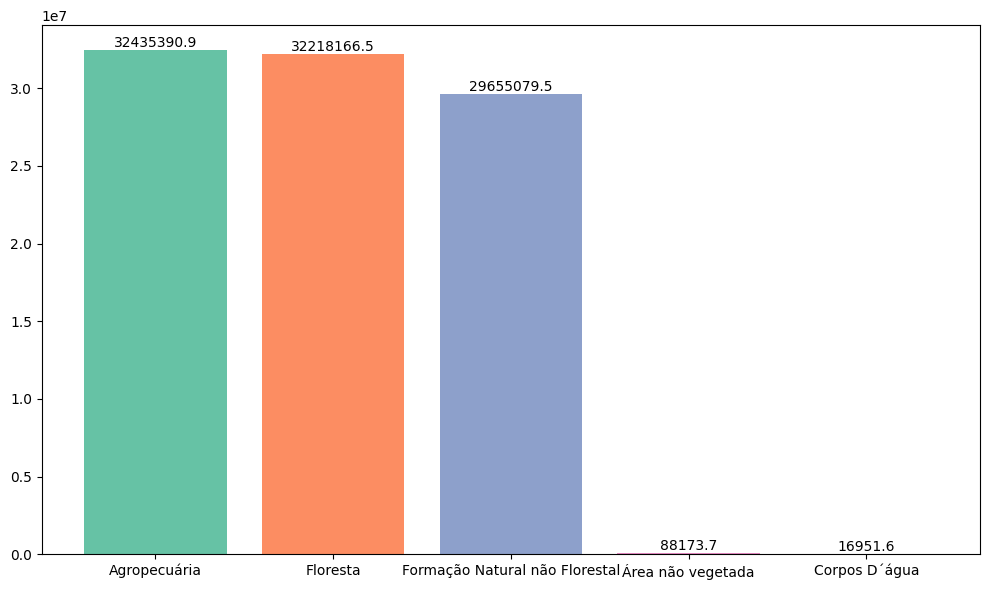

In [ ]:
valores_area_queimada = df_monitor_fogo.groupby('Tipo_uso')['Area_queimada_ha'].sum()
utils.plot_bar_chart(data=valores_area_queimada.values, labels=valores_area_queimada.index, title="Comparação por tipo de uso")

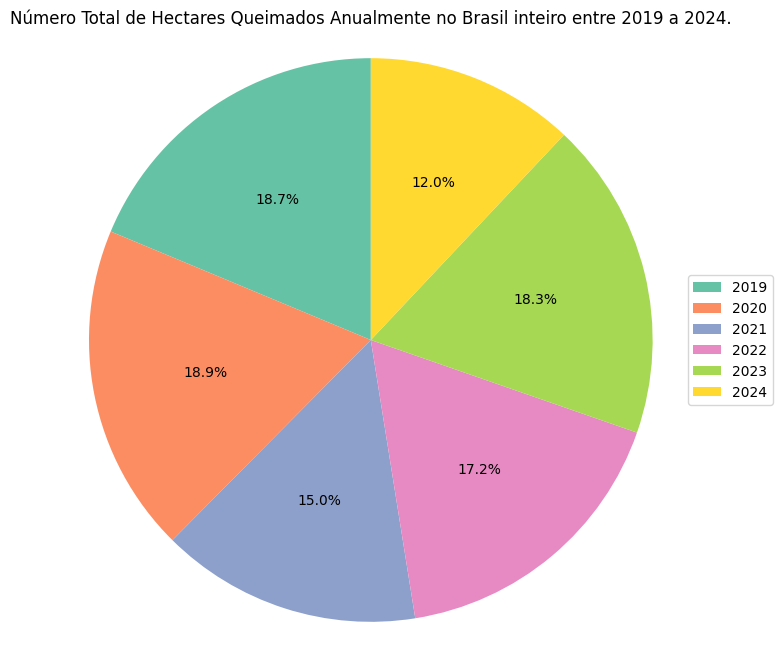

In [ ]:
df_monitor_fogo_agrupados_ano = df_monitor_fogo.groupby(['Ano'])['Area_queimada_ha'].sum()
utils.plot_pie_chart(data=df_monitor_fogo_agrupados_ano.values,labels=df_monitor_fogo_agrupados_ano.index, title="Número Total de Hectares Queimados Anualmente no Brasil inteiro entre 2019 a 2024.")

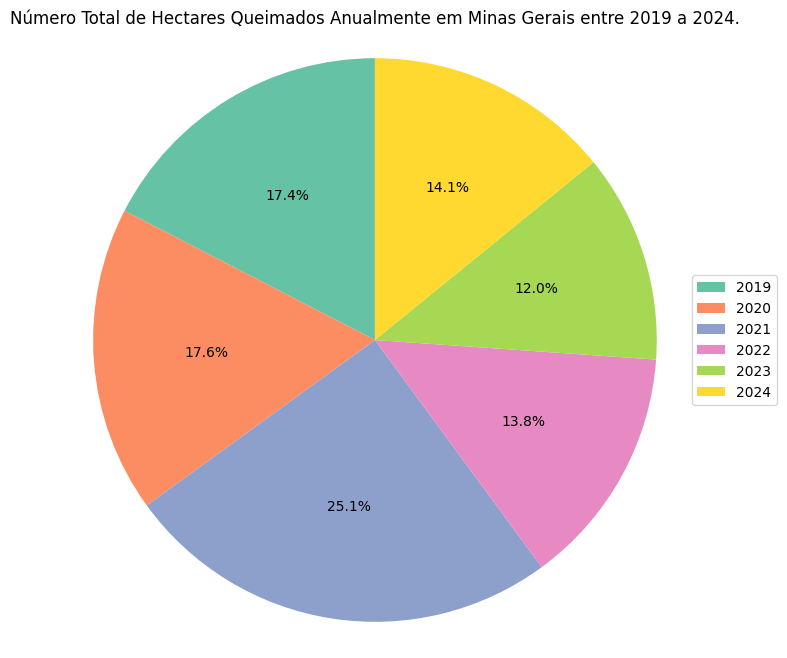

In [ ]:
df_monitor_fogo_agrupados_ano = df_monitor_fogo_mg.groupby(['Ano'])['Area_queimada_ha'].sum()
utils.plot_pie_chart(data=df_monitor_fogo_agrupados_ano.values,labels=df_monitor_fogo_agrupados_ano.index, title="Número Total de Hectares Queimados Anualmente em Minas Gerais entre 2019 a 2024.")

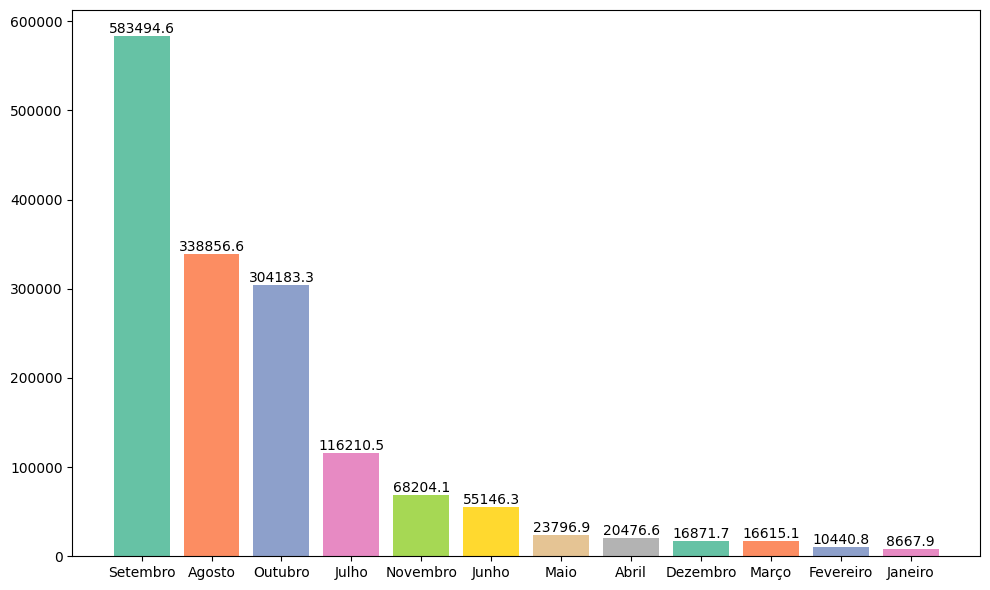

In [ ]:
somatorio_area_queimada = df_monitor_fogo_mg.groupby('Mes_nome')['Area_queimada_ha'].sum()
utils.plot_bar_chart(data=somatorio_area_queimada.values, labels=somatorio_area_queimada.index)

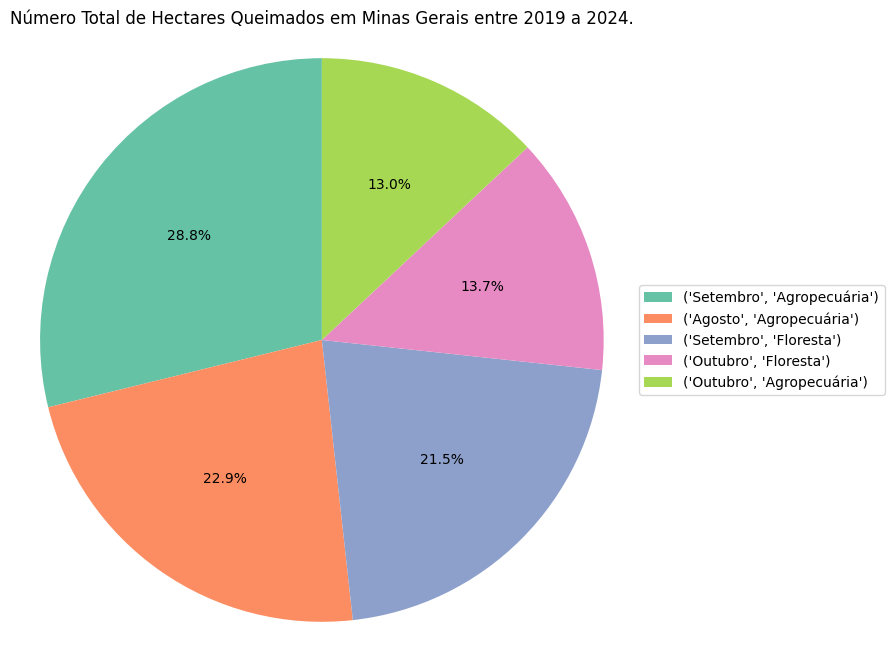

In [ ]:
df_monitor_fogo_agrupados_ano = df_monitor_fogo_mg.groupby(["Mes_nome", "Tipo_uso"])["Area_queimada_ha"].sum().sort_values(ascending=False).head(5)


utils.plot_pie_chart(data=df_monitor_fogo_agrupados_ano.values,labels=df_monitor_fogo_agrupados_ano.index, title="Número Total de Hectares Queimados em Minas Gerais entre 2019 a 2024.")

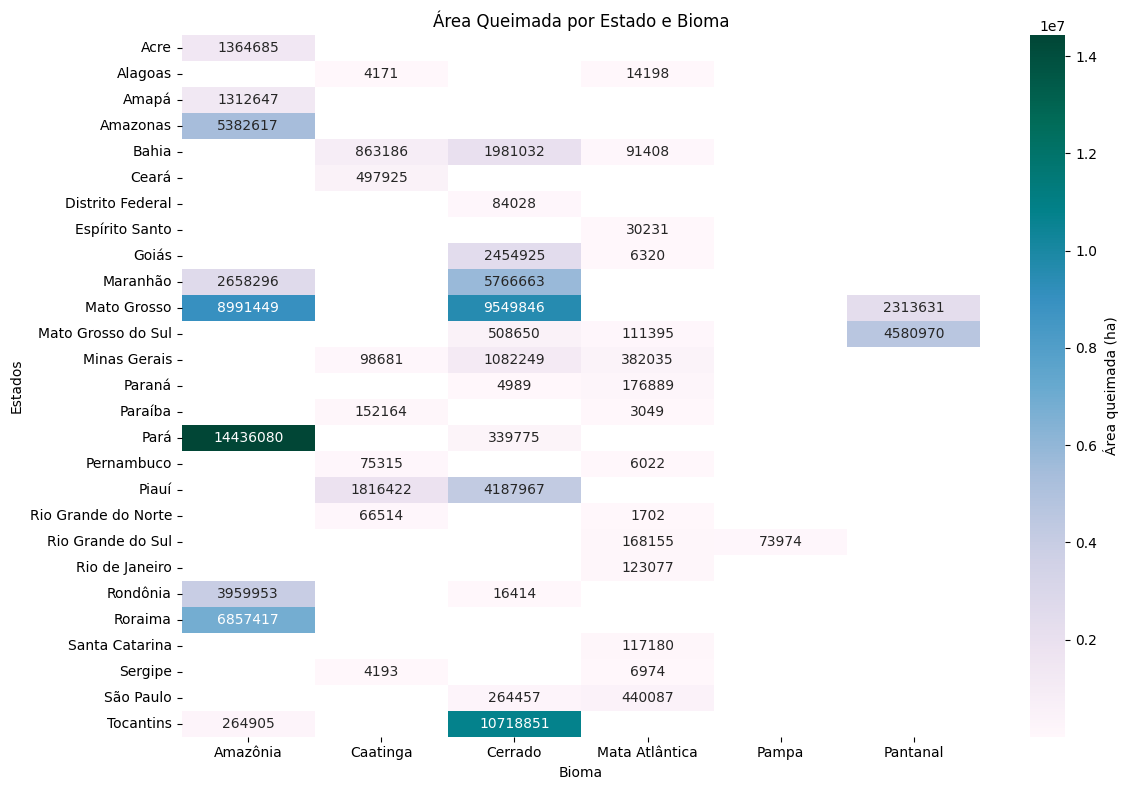

In [ ]:
utils.plot_heatmap(
    df=df_monitor_fogo,
    values='Área queimada (ha)',
    index='Estados',
    columns='Bioma',
    cmap='PuBuGn',
    fmt=".0f",
    title='Área Queimada por Estado e Bioma'
)

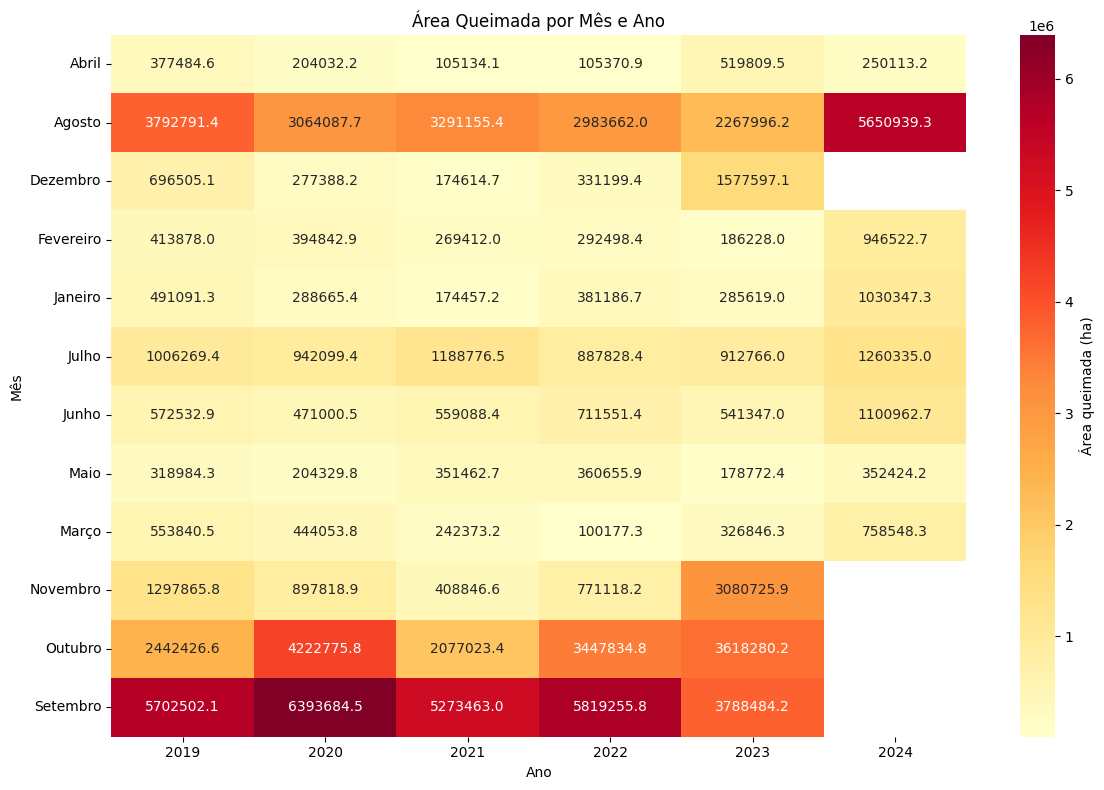

In [ ]:
utils.plot_heatmap(
    df=df_monitor_fogo,
    values='Área queimada (ha)',
    index='Mês',
    columns='Ano',
    cmap='YlOrRd',
    title='Área Queimada por Mês e Ano',
    figsize=(12,8)
)

In [ ]:
del df_monitor_fogo_agrupados_ano

#### BDMEP

In [ ]:
df_dados_BDMEP.columns

Index(['ano', 'mes', 'data_hora', 'bioma', 'sigla_uf', 'sigla_uf_nome',
       'id_municipio', 'id_municipio_nome', 'latitude', 'longitude',
       'satelite', 'dias_sem_chuva', 'precipitacao', 'risco_fogo',
       'potencia_radiativa_fogo', 'Data', 'Hora', 'Ano', 'Mes', 'Dia'],
      dtype='object')

In [ ]:
# Ordenar por município e tempo
df_dados_BDMEP = df_dados_BDMEP.sort_values(by=['id_municipio', 'data_hora'])

# FRP médio por município
df_dados_BDMEP['frp_medio_municipio'] = df_dados_BDMEP.groupby('id_municipio')['potencia_radiativa_fogo'].transform('mean')

# FRP máximo
df_dados_BDMEP['frp_max'] = df_dados_BDMEP.groupby('id_municipio')['potencia_radiativa_fogo'].transform('max')

# FRP normalizado (0 a 1)
df_dados_BDMEP['frp_norm'] = (
    (df_dados_BDMEP['potencia_radiativa_fogo'] - df_dados_BDMEP['potencia_radiativa_fogo'].min()) /
    (df_dados_BDMEP['potencia_radiativa_fogo'].max() - df_dados_BDMEP['potencia_radiativa_fogo'].min())
)

# Índice simples de seca: dias sem chuva / (precipitação + 1)
df_dados_BDMEP['indice_seca'] = df_dados_BDMEP['dias_sem_chuva'] / (df_dados_BDMEP['precipitacao'] + 1)

# Precipitação acumulada 7 dias
df_dados_BDMEP['precipitacao_7d'] = df_dados_BDMEP.groupby('id_municipio')['precipitacao'].transform(lambda x: x.rolling(7, min_periods=1).sum())

# Anomalia de precipitação (z-score por município)
df_dados_BDMEP['anomalia_precipitacao'] = df_dados_BDMEP.groupby('id_municipio')['precipitacao'].transform(lambda x: (x - x.mean()) / x.std())

# Risco suavizado (média móvel 7 dias)
df_dados_BDMEP['risco_movel_7d'] = df_dados_BDMEP.groupby('id_municipio')['risco_fogo'].transform(lambda x: x.rolling(7, min_periods=1).mean())

# Variação diária do risco
df_dados_BDMEP['delta_risco'] = df_dados_BDMEP.groupby('id_municipio')['risco_fogo'].diff()

# Índice composto de risco: risco × seca × FRP normalizado
df_dados_BDMEP['risco_composto'] = df_dados_BDMEP['risco_fogo'] * df_dados_BDMEP['indice_seca'] * df_dados_BDMEP['frp_norm']

In [ ]:
df_dados_BDMEP.head()

,ano,mes,data_hora,bioma,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,latitude,longitude,satelite,dias_sem_chuva,precipitacao,risco_fogo,potencia_radiativa_fogo,Data,Hora,Ano,Mes,Dia
0,2023,3,2023-03-24 04:38:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.36515,-47.46853,NPP-375D,4.0,0.00,0.20,0.4,2023-03-24,04:38:00,2023,3,24
1,2023,3,2023-03-24 04:38:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.36575,-47.46425,NPP-375D,4.0,0.00,0.20,0.4,2023-03-24,04:38:00,2023,3,24
2,2023,3,2023-03-25 04:17:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.36529,-47.46562,NPP-375D,5.0,0.00,0.30,0.5,2023-03-25,04:17:00,2023,3,25
3,2023,3,2023-03-30 03:34:00,Cerrado,MG,Minas Gerais,3100104,Abadia dos Dourados,-18.42563,-47.48619,NOAA-20,3.0,0.25,0.15,1.7,2023-03-30,03:34:00,2023,3,30
4,2023,1,2023-01-16 04:42:00,Cerrado,MG,Minas Gerais,3100203,Abaeté,-18.99268,-45.23447,NOAA-20,1.0,0.50,0.00,2.3,2023-01-16,04:42:00,2023,1,16


In [ ]:
df_dados_BDMEP.to_parquet(config_path.FEATURES_DIRECTORY_PATH / "df_dados_BDMEP.parquet")

In [ ]:
df_mun_area

,ID_UF,Nome_UF,UF_SIGLA,ID_Município,Nome_Município,AreaKm2_Mun_2024
0,11,Rondônia,RO,1101203.0,Ministro Andreazza,798.083
1,11,Rondônia,RO,1101708.0,Urupá,831.857
2,11,Rondônia,RO,1100403.0,Alto Paraíso,2651.991
3,11,Rondônia,RO,1100452.0,Buritis,3265.810
4,11,Rondônia,RO,1101757.0,Vale do Anari,3135.106
...,...,...,...,...,...,...
5568,52,Goiás,GO,5202502.0,Aruanã,3054.773
5569,52,Goiás,GO,5210802.0,Itajá,2082.737
5570,52,Goiás,GO,5213855.0,Morro Agudo de Goiás,282.333
5571,52,Goiás,GO,5201207.0,Anhanguera,55.569


#### NASA FIRMS

In [ ]:


# --- 1. Baixar os dados do FIRMS ---
# Exemplo: MODIS Active Fire Data (últimos 7 dias) para o Brasil
url = f"https://firms.modaps.eosdis.nasa.gov/api/csv/active_fire/c6/country/BR?apiKey={NASA_FIRMS_API_KEY}"

response = requests.get(url)
if response.status_code != 200:
    print(response.status_code)
    raise Exception("Erro ao baixar dados do FIRMS. Verifique sua API key e URL.")

# Ler CSV em pandas
data = StringIO(response.text)
df = pd.read_csv(data)

# --- 2. Pré-processamento ---
# Converter data para datetime
df['acq_date'] = pd.to_datetime(df['acq_date'])

# Contar número de focos por dia
fires_per_day = df.groupby('acq_date').size().reset_index(name='num_focos')

# --- 3. Plotar gráfico ---
plt.figure(figsize=(12,6))
sns.lineplot(data=fires_per_day, x='acq_date', y='num_focos', marker='o')
plt.title('Número de focos de queimadas no Brasil (últimos dias)')
plt.xlabel('Data')
plt.ylabel('Número de focos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

400


Exception: Erro ao baixar dados do FIRMS. Verifique sua API key e URL.